In [1]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

In [ ]:
model = load_model(r"models\violence_detection_model.h5")

print("Model loaded successfully")

Model loaded successfully


In [15]:
import cv2
import numpy as np
from collections import deque

def detect_violence_in_video(video_path):

    cap = cv2.VideoCapture(video_path)

    frame_buffer = deque(maxlen=32)
    prediction_buffer = deque(maxlen=10)

    label = "Initializing..."
    color = (255,255,0)

    while True:

        ret, frame = cap.read()
        if not ret:
            break

        display = frame.copy()

        # preprocess frame
        img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (160,160))
        img = img / 255.0

        frame_buffer.append(img)

        if len(frame_buffer) == 32:

            # uniform sampling
            idx = np.linspace(0,31,16).astype(int)
            sampled = [frame_buffer[i] for i in idx]

            input_frames = np.expand_dims(sampled, axis=0)

            prediction = model.predict(input_frames, verbose=0)[0][0]

            prediction_buffer.append(prediction)

            # smooth prediction
            avg_pred = np.mean(prediction_buffer)

            if avg_pred > 0.7:
                label = "VIOLENCE"
                color = (0,0,255)
            else:
                label = "NON-VIOLENCE"
                color = (0,255,0)

        cv2.putText(display, label, (20,40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)

        cv2.imshow("Violence Detection", display)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

In [17]:
video_path = r"C:\Users\anush\Downloads\WhatsApp Video 2026-03-09 at 4.58.36 PM.mp4"

detect_violence_in_video(video_path)

In [11]:
import cv2
import numpy as np

def webcam_violence_detection():

    cap = cv2.VideoCapture(0)

    frame_buffer = []
    pred_buffer = []

    label = "SAFE"
    color = (0,255,0)

    prev_gray = None

    while True:

        ret, frame = cap.read()
        if not ret:
            break

        display = frame.copy()

        # -------- Motion Detection --------
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        motion_level = 0

        if prev_gray is not None:
            diff = cv2.absdiff(prev_gray, gray)
            motion_level = np.mean(diff)

        prev_gray = gray

        # If motion is very small → SAFE
        if motion_level < 2.5:
            label = "SAFE"
            color = (0,255,0)

        else:

            img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img,(160,160))
            img = img / 255.0

            frame_buffer.append(img)

            if len(frame_buffer) > 16:
                frame_buffer.pop(0)

            if len(frame_buffer) == 16:

                input_frames = np.expand_dims(frame_buffer, axis=0)

                prediction = model.predict(input_frames, verbose=0)[0][0]

                pred_buffer.append(prediction)

                if len(pred_buffer) > 5:
                    pred_buffer.pop(0)

                avg_pred = np.mean(pred_buffer)

                print("Prediction:", avg_pred)

                if avg_pred > 0.2:
                    label = "VIOLENCE"
                    color = (0,0,255)
                else:
                    label = "SAFE"
                    color = (0,255,0)

        cv2.putText(display,label,(20,40),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    1,color,2)

        cv2.imshow("Webcam Violence Detection",display)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

In [12]:
webcam_violence_detection()

Prediction: 1.6406877e-05
Prediction: 1.7574948e-05
Prediction: 1.91277e-05
Prediction: 2.0539625e-05
Prediction: 2.138066e-05
Prediction: 2.3046432e-05
Prediction: 2.4755664e-05
Prediction: 2.4964049e-05
Prediction: 2.4980885e-05
Prediction: 2.5573245e-05
Prediction: 2.5776255e-05
Prediction: 2.5191417e-05
Prediction: 2.550433e-05
Prediction: 2.5794207e-05
Prediction: 2.5504307e-05
Prediction: 2.6250782e-05
Prediction: 2.7221864e-05
Prediction: 2.8115688e-05
Prediction: 2.8455568e-05
Prediction: 2.8828668e-05
Prediction: 2.8658444e-05
Prediction: 2.8448509e-05
Prediction: 2.7720796e-05
Prediction: 2.7798034e-05
Prediction: 2.801037e-05
Prediction: 2.8656945e-05
Prediction: 2.9454226e-05
Prediction: 3.0303414e-05
Prediction: 2.9727173e-05
Prediction: 2.7969232e-05
Prediction: 2.5283778e-05
Prediction: 2.178355e-05
Prediction: 1.8990588e-05
Prediction: 1.7311488e-05
Prediction: 1.6318121e-05
Prediction: 1.5575188e-05
Prediction: 1.566954e-05
Prediction: 1.5249799e-05
Prediction: 1.43511

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def predict_video_16_frames(video_path):

    cap = cv2.VideoCapture(video_path)

    frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame_rgb)

    cap.release()

    total_frames = len(frames)

    # uniformly sample 16 frames across video
    indices = np.linspace(0, total_frames - 1, 16).astype(int)
    sampled_frames = [frames[i] for i in indices]

    processed_frames = []

    for frame in sampled_frames:
        img = cv2.resize(frame, (160,160))
        img = img / 255.0
        processed_frames.append(img)

    input_frames = np.expand_dims(processed_frames, axis=0)

    prediction = model.predict(input_frames, verbose=0)[0][0]

    if prediction > 0.5:
        label = "VIOLENCE"
        color = "red"
    else:
        label = "NON-VIOLENCE"
        color = "green"

    # show frames in notebook
    plt.figure(figsize=(15,6))

    for i, frame in enumerate(sampled_frames):
        plt.subplot(2,8,i+1)
        plt.imshow(frame)
        plt.axis("off")

    plt.suptitle(f"Prediction: {label}  (score={prediction:.2f})",
                 fontsize=16, color=color)

    plt.show()

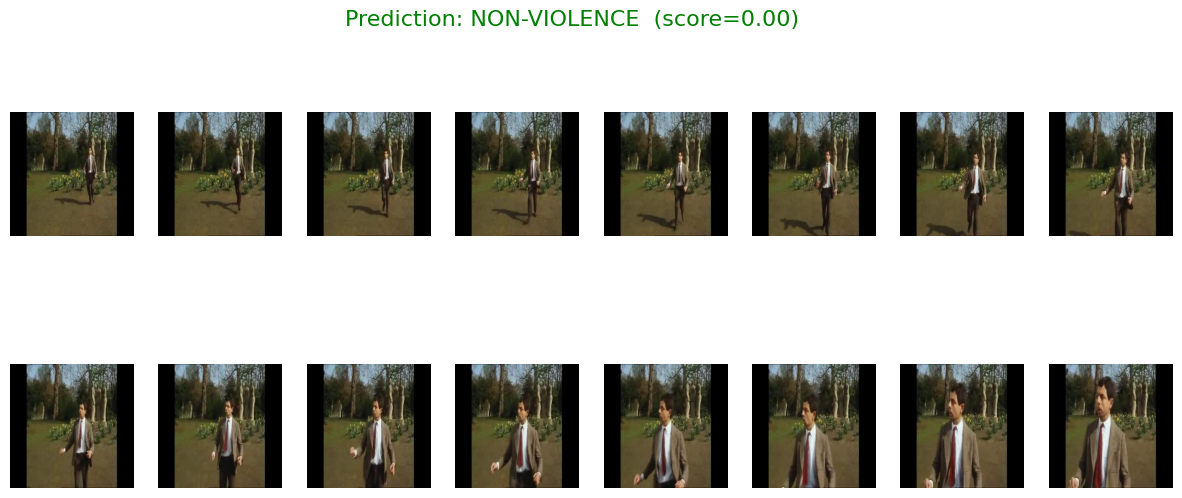

In [14]:
video_path = r"C:\Violence-detection\dataset\Real Life Violence Dataset\NonViolence\NV_394.mp4"

predict_video_16_frames(video_path)